In [8]:
import sys
print(sys.executable)

/opt/anaconda3/envs/deepfake_gpu/bin/python


In [9]:
import cv2
import numpy as np
from ultralytics import YOLO

print("All good")

All good


In [10]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

print("Model loaded successfully ")

Model loaded successfully 



0: 480x640 2 cars, 83.2ms
Speed: 3.6ms preprocess, 83.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


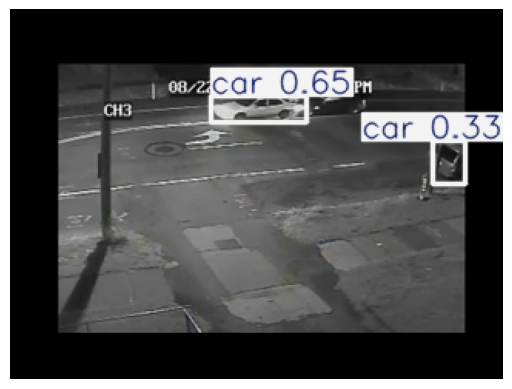

In [11]:
from pathlib import Path
import cv2

sample_image = Path("archive/Accident/Accident/6.jpg")

img = cv2.imread(str(sample_image))

if img is None:
    print(f"Image not found: {sample_image}")
else:
    results = model(img)
    annotated = results[0].plot()

    # Use matplotlib (safer in notebook)
    from matplotlib import pyplot as plt
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [12]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2
import numpy as np
from pathlib import Path

# Load model
model = YOLO("yolov8n.pt")

# Tracker
tracker = DeepSort(max_age=20)

# Input source: set to a video file path if you do not want to use the webcam
video_source = 0
cap = cv2.VideoCapture(video_source)

if not cap.isOpened():
    raise RuntimeError("Could not open video source. Update 'video_source' before running this cell.")

# Output video
frame_width, frame_height = 480, 360
fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter("output.avi", fourcc, 20.0, (frame_width, frame_height))

# Variables
prev_frame = None
frame_count = 0
detection_interval = 5
all_track_ids = set()
tracks = []

# Log file
log_path = Path("log.txt")
log_file = open(log_path, "w")
log_file.write("frame,current_people,total_unique_people,motion_level\n")

print("Press q to exit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (frame_width, frame_height))
    frame_count += 1
    detections = []

    # -------- YOLO DETECTION --------
    if frame_count % detection_interval == 0:
        results = model(frame, verbose=False)

        for r in results:
            for box in r.boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])

                if cls == 0 and conf >= 0.4:  # person
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    w = x2 - x1
                    h = y2 - y1
                    detections.append(([x1, y1, w, h], conf, "person"))

        tracks = tracker.update_tracks(detections, frame=frame)
    else:
        tracks = tracker.update_tracks([], frame=frame)

    # -------- TRACKING DRAW --------
    current_track_ids = set()

    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        left, top, right, bottom = map(int, track.to_ltrb())

        current_track_ids.add(track_id)
        all_track_ids.add(track_id)

        cv2.rectangle(frame, (left, top), (right, bottom), (255, 0, 0), 2)
        cv2.putText(frame, f"ID {track_id}",
                    (left, max(top - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    2)

    current_people = len(current_track_ids)
    total_unique_people = len(all_track_ids)

    # -------- MOTION DETECTION --------
    if prev_frame is not None and frame_count % detection_interval == 0:
        gray1 = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        gray1 = cv2.GaussianBlur(gray1, (7, 7), 0)
        gray2 = cv2.GaussianBlur(gray2, (7, 7), 0)

        diff = cv2.absdiff(gray1, gray2)
        _, thresh = cv2.threshold(diff, 50, 255, cv2.THRESH_BINARY)

        kernel = np.ones((5, 5), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        motion_level = int(np.sum(thresh) / 255)
        cv2.imshow("Motion", thresh)
    else:
        motion_level = 0

    prev_frame = frame.copy()

    # -------- STATS DISPLAY --------
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 1:
        fps = 20

    cv2.putText(frame, f"Current People: {current_people}",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2.putText(frame, f"Total Unique People: {total_unique_people}",
                (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    cv2.putText(frame, f"FPS: {int(fps)}",
                (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    cv2.putText(frame, f"Motion: {motion_level}",
                (10, 120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)

    # -------- ALERT --------
    if current_people > 3:
        cv2.putText(frame, "ALERT: Crowd Detected!",
                    (10, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # -------- LOG --------
    log_file.write(f"{frame_count},{current_people},{total_unique_people},{motion_level}\n")

    # -------- SAVE VIDEO --------
    out.write(frame)

    # -------- DISPLAY --------
    cv2.imshow("Smart Surveillance", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# -------- CLEANUP --------
cap.release()
out.release()
log_file.close()
cv2.destroyAllWindows()

Press q to exit


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

log_path = Path("log.txt")

if not log_path.exists():
    print("Run the surveillance cell first so log.txt gets created.")
else:
    df = pd.read_csv(log_path)
    plt.plot(df["frame"], df["current_people"], label="Current People")
    plt.plot(df["frame"], df["total_unique_people"], label="Total Unique People")
    plt.xlabel("Frame Number")
    plt.ylabel("People Count")
    plt.title("People Count Over Time")
    plt.legend()
    plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

evaluation_path = Path("evaluation_labels.csv")

if not evaluation_path.exists():
    print("Optional evaluation: create evaluation_labels.csv with columns y_true and y_pred.")
else:
    eval_df = pd.read_csv(evaluation_path)
    y_true = eval_df["y_true"]
    y_pred = eval_df["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
if "evaluation_path" not in globals() or not evaluation_path.exists():
    print("No evaluation_labels.csv found, so accuracy is skipped.")
else:
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    accuracy = correct / len(y_true)
    print("Accuracy:", accuracy)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

if "evaluation_path" not in globals() or not evaluation_path.exists():
    print("No evaluation_labels.csv found, so precision, recall, and F1 are skipped.")
else:
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

In [ ]:
if "df" not in globals():
    print("Run the log analysis cell first so df is created.")
else:
    df["current_people_smooth"] = df["current_people"].rolling(window=3).mean()
    plt.plot(df["frame"], df["current_people"], label="Current People")
    plt.plot(df["frame"], df["current_people_smooth"], label="Smoothed Current People")
    plt.legend()
    plt.title("Current People Trend")
    plt.show()